# Regularization

## Step 0: Define a dataset

In [1]:
import os
import numpy as np
import pandas as pd

try:
    s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    print('From URL:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

except HTTPError:
    s = 'iris.data'
    print('From local Iris path:', s)
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
There are 3 categories: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Fitting a dataset with X: (100, 2) and y: (100,)


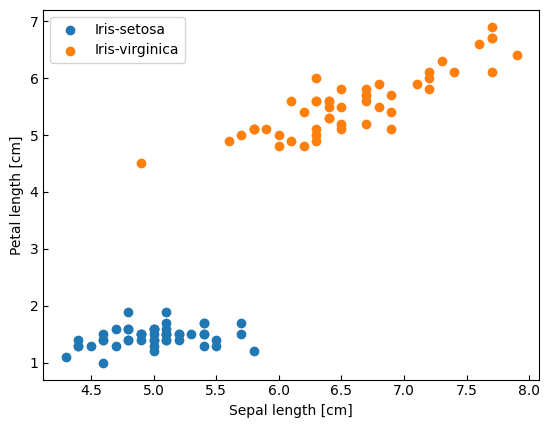

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# We are going to classify Iris-setosa from Iris virginica
labels = ['Iris-setosa', 'Iris-virginica']
mask = df[4].isin(labels)
df = df.loc[mask]

X = df[[0, 2]].values
y = df[4].values
y_mapped = np.zeros(y.shape, dtype=int)
y_mapped[y == labels[1]] = 1

print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend()

## Step 1: Define and fit Logistic Regression model

In [ ]:
import numpy as np

def cross_entropy(y, y_model, eps=1e-10):
    return -y.dot(np.log(y_model + eps)) - (1-y).dot(np.log(1-y_model + eps))

class LogisticRegression:
    """ Gradient descent variant
        
        Parameters:
        -----------
        eta : float - Learning rate between 0 and 1
        n_epochs : int - Iterations over the training set
        batch_size : int - Size of each mini-batch
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        losses_ : MSE loss each epoch
    """
    def __init__(self, 
                 eta=0.25, 
                 n_epochs=100, 
                 random_seed=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """

        self.X_mean_ = X.mean(axis=0)
        self.X_std_ = X.std(axis=0)
        X_std = self._standardize(X)

        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float_(0.)

        self.losses_ = []

        # iterate over epochs
        for _ in range(self.n_epochs):
             loss = self._fit_epoch(X_std, y)
             self.losses_.append(loss)

        return self

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)
        diff = y - pred

        self.w_ += 2. * self.eta * diff.dot(X) / X.shape[0]
        self.b_ += 2. * self.eta * diff.mean()

        loss = cross_entropy(y, pred)

        return loss

    def _standardize(self, X):
        return (X - self.X_mean_) / self.X_std_

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        X_std = self._standardize(X)
        z = self.pre_activation(X_std)
        y = self.activation(z)
        return np.where(y >= 0.5, 1, 0)

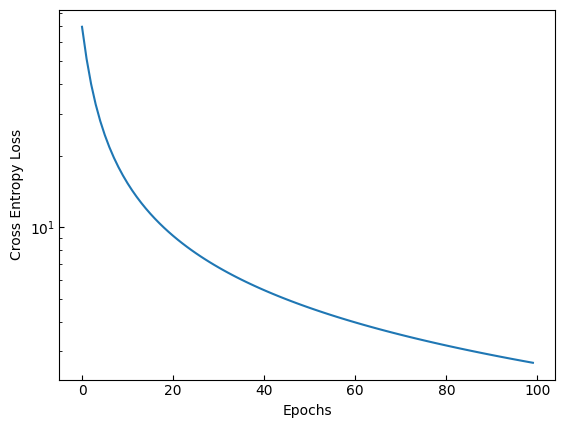

In [4]:
lr_model = LogisticRegression()
lr_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(lr_model.losses_)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

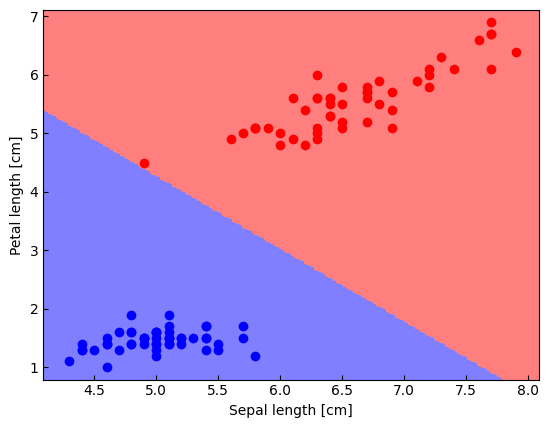

In [5]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    y_model = model.predict(np.stack([x1.ravel(), x2.ravel()]).T)
    y_model = y_model.reshape(x1.shape)

    pred_mask = model.predict(X) == y

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for ii, label in enumerate(np.unique(y)):
        label_mask = y == label
        ax.scatter(X[label_mask & pred_mask, 0], X[label_mask & pred_mask, 1], 
                   facecolor=colors[label], edgecolor=colors[label])
        ax.scatter(X[label_mask & ~pred_mask, 0], X[label_mask & ~pred_mask, 1], 
                   facecolor='white', edgecolor=colors[label])
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_mapped, lr_model)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')

## Step 2: Define and fit polynomial Logistic Regression model

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

class LogisticRegressionPolynomial:
    """ Gradient descent variant with polynomial features
        
        Parameters:
        -----------
        eta : float - Learning rate between 0 and 1
        degree : int - Maximum polynomial degree
        n_epochs : int - Iterations over the training set
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
        losses_ : MSE loss each epoch
    """
    def __init__(self, 
                 eta=0.25, 
                 degree=1,
                 n_epochs=100, 
                 random_seed=42):
        self.eta = eta
        self.degree = degree
        self.n_epochs = n_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """

        self.X_mean_ = X.mean(axis=0)
        self.X_std_ = X.std(axis=0)
        X_std = self._standardize(X)

        # Pre-transforms: polynomial features
        self.poly_ = PolynomialFeatures(self.degree, include_bias=False)
        X_poly = self.poly_.fit_transform(X_std)

        self.rng = np.random.default_rng(seed=self.random_seed)
        self.w_ = self.rng.normal(loc=0, scale=0.01, size=X_poly.shape[1])
        self.b_ = np.float_(0.)

        self.losses_ = []

        # iterate over epochs
        for _ in range(self.n_epochs):
             loss = self._fit_epoch(X_poly, y)
             self.losses_.append(loss)

        return self

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)
        diff = y - pred

        self.w_ += 2. * self.eta * diff.dot(X) / X.shape[0]
        self.b_ += 2. * self.eta * diff.mean()

        loss = cross_entropy(y, pred)

        return loss

    def _standardize(self, X):
        return (X - self.X_mean_) / self.X_std_

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        X_std = self._standardize(X)
        X_poly = self.poly_.transform(X_std)
        z = self.pre_activation(X_poly)
        y = self.activation(z)
        return np.where(y >= 0.5, 1, 0)

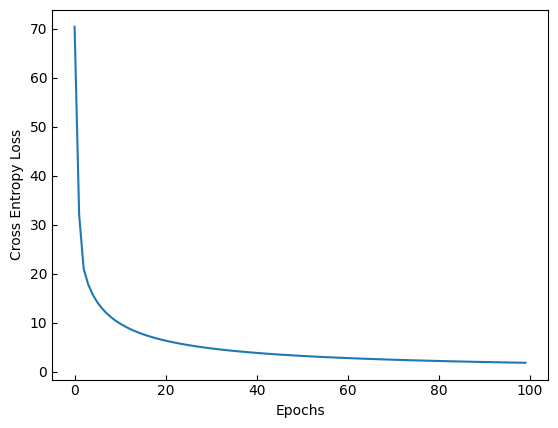

In [7]:
lr_model = LogisticRegressionPolynomial(degree=4)
lr_model.fit(X, y_mapped)

ax = plt.figure().gca()
ax.plot(lr_model.losses_)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss');

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

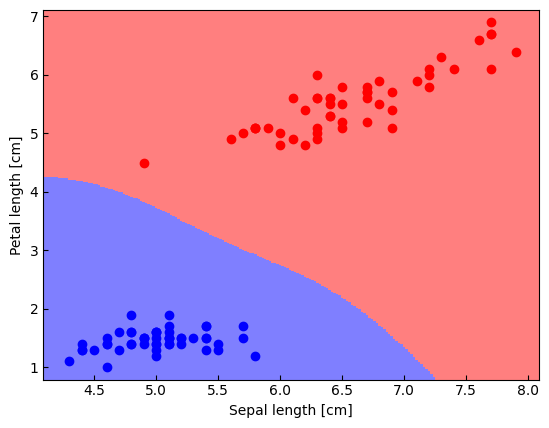

In [8]:
ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_mapped, lr_model)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')

## Step 3: What if we add more polynomials?

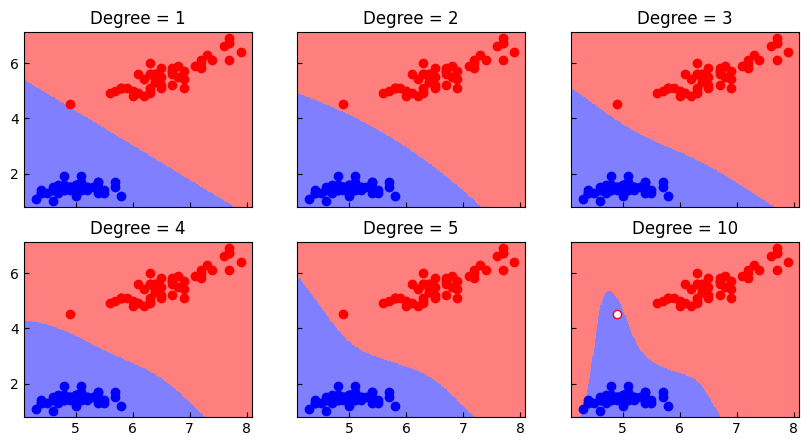

In [9]:
degrees = [1, 2, 3, 4, 5, 10]
ax_db = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 5))[1].flatten()

for ii, degree in enumerate(degrees):
    model = LogisticRegressionPolynomial(degree=degree)
    model.fit(X, y_mapped)

    plot_decision_boundary(ax_db[ii], X, y_mapped, model)
    ax_db[ii].set_title(f'Degree = {degree}')

## Step 4 - Add Regularization

In [10]:
class LogisticRegressionPolynomialL2(LogisticRegressionPolynomial):
    """ L2-regularized logistic regression
        -----------
        alpha : float - L1 regularization constant
    """
    def __init__(self, alpha=0.05, **kwargs):
        self.alpha = alpha
        super().__init__(**kwargs)

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)
        diff = y - pred

        self.w_ += self.eta * (2. * diff.dot(X) / X.shape[0] - self.alpha * self.w_)
        self.b_ += self.eta * 2. * diff.mean()

        return cross_entropy(y, pred) + 0.5 * self.alpha * np.sum(self.w_**2)

class LogisticRegressionPolynomialL1(LogisticRegressionPolynomial):
    """ L1-regularized logistic regression
        -----------
        alpha : float - L1 regularization constant
    """
    def __init__(self, alpha=0.05, **kwargs):
        self.alpha = alpha
        super().__init__(**kwargs)

    def _fit_epoch(self, X, y):
        z = self.pre_activation(X)
        pred = self.activation(z)
        diff = y - pred

        self.w_ += self.eta * (diff.dot(X) / X.shape[0] - self.alpha * np.sign(self.w_))
        self.b_ += self.eta * diff.mean()

        return cross_entropy(y, pred) + self.alpha * np.sum(np.abs(self.w_))

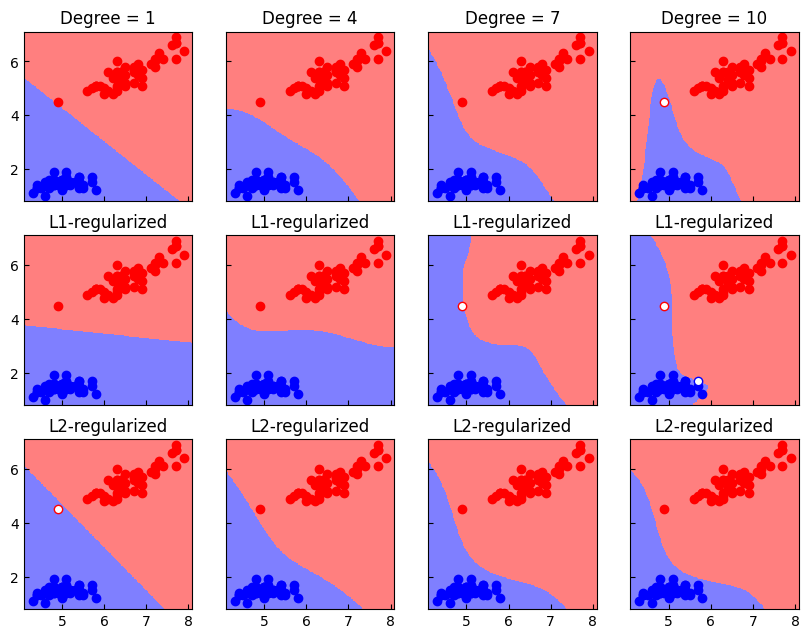

In [11]:
degrees = [1, 4, 7, 10]
ax_db = plt.subplots(3, 4, sharex=True, sharey=True, figsize=(10, 7.5))[1]

for ii, degree in enumerate(degrees):
    model = LogisticRegressionPolynomial(degree=degree).fit(X, y_mapped)
    plot_decision_boundary(ax_db[0, ii], X, y_mapped, model)

    model = LogisticRegressionPolynomialL1(alpha=0.25, degree=degree).fit(X, y_mapped)
    plot_decision_boundary(ax_db[1, ii], X, y_mapped, model)


    model = LogisticRegressionPolynomialL2(alpha=0.5, degree=degree).fit(X, y_mapped)
    plot_decision_boundary(ax_db[2, ii], X, y_mapped, model)

    ax_db[0, ii].set_title(f'Degree = {degree}')
    ax_db[1, ii].set_title(f'L1-regularized')
    ax_db[2, ii].set_title(f'L2-regularized')

## Step 5 - Try a nonlinear problem

[Text(0.5, 0, '$x_0$'), Text(0, 0.5, '$x_1$'), None]

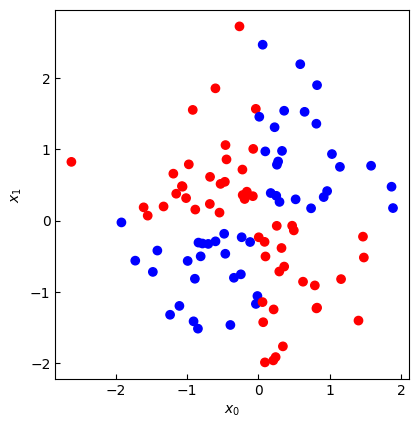

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

def make_xor_dataset(N=100, random_seed=42):
    np.random.seed(random_seed)
    X = np.random.randn(N, 2)
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X_nl, y_nl = make_xor_dataset()

ax = plt.figure().gca()
ax.scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal')

[Text(0.5, 0, '$x_0$'), Text(0, 0.5, '$x_1$')]

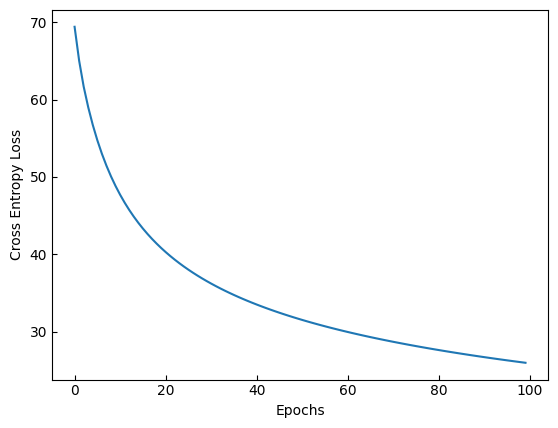

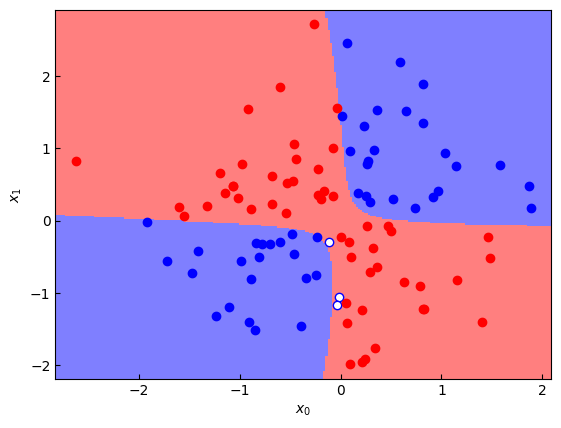

In [13]:
lr_model = LogisticRegressionPolynomial(degree=3)
lr_model.fit(X_nl, y_nl)

ax = plt.figure().gca()
ax.plot(lr_model.losses_)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss');

ax = plt.figure().gca()
plot_decision_boundary(ax, X_nl, y_nl, lr_model)
ax.set(xlabel='$x_0$', ylabel='$x_1$')